# S&P 500 Sektör ETF'leri — Makroekonomik Olay Çalışması
## Keşifsel Veri Analizi, Görselleştirme ve Hipotez Testleri

Bu notebook'ta **5 büyük makro olayın** (2016 ABD Seçimleri, COVID-19, Rusya–Ukrayna Savaşı, 2024 ABD Seçimleri, İsrail–İran Gerilimi) S&P 500 sektör ETF'lerine etkisini inceliyoruz.

**Akış:**
1. **Hazırlık** — Kütüphaneler ve yardımcı araçlar
2. **Veri Hazırlığı** — Anormal Getiri (AR) hesabı (Sektör − SPY)
3. **Görselleştirmeler** — CAR ve Volatilite şoku
4. **Korelasyon & Dağılım** — Isı haritası ve boxplot
5. **Hipotez Testleri** — Agregre, sektör bazlı T=0 ve CAR testleri
6. **Sonuç ve Çıkarımlar**


---
## 1. Hazırlık — Kütüphaneler, Stil ve Yardımcı Fonksiyon


In [2]:
# ===========================================================
# Tüm import'lar, görsel tema ayarları ve t-testi yardımcı fonksiyonu
# bu tek hücrede toplanır. Sunumda hızlıca geçilecek.
# ===========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# --- Görsel tema ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"]      = 120
plt.rcParams["axes.titlesize"]  = 14
plt.rcParams["axes.labelsize"]  = 12

# --- Yardımcı fonksiyon: tek-örneklem t-testini "siyah kutu" olarak sarmalar ---
# Girdi:  bir sayısal seri (AR ya da CAR)
# Çıktı:  n, ortalama, std, t-istatistiği, p-değeri ve anlamlılık etiketi
def t_test_sonuc(seri, popmean=0):
    s = seri.dropna()
    t, p = stats.ttest_1samp(s, popmean)
    return pd.Series({
        "n":            len(s),
        "Ortalama":     s.mean(),
        "Std":          s.std(),
        "t_istatistik": t,
        "p_deger":      p,
        "Anlamli_p05":  "EVET" if p < 0.05 else "Hayir",
    })

print("Kütüphaneler ve yardımcı araçlar hazır.")

Kütüphaneler ve yardımcı araçlar hazır.


---
## 2. Veri Hazırlığı ve Anormal Getiri Hesabı

**Anormal Getiri (AR):** Sektörün getirisi ile piyasa benchmark'ı (SPY) arasındaki fark.
Eğer SPY %1 düşmüş, XLE %3 düşmüşse → XLE'nin AR'si %−2'dir.


In [3]:
# ===========================================================
# 1. Adım: Ham veriyi oku ve Hacim_Degisimi sütunundaki +/-inf
#          değerlerini NaN'a çevirip ileriye doldur (ffill).
# ===========================================================
df_ham = (pd.read_csv("sp500_olay_calismasi_ham_veri.csv")
            .assign(Hacim_Degisimi=lambda d: d["Hacim_Degisimi"]
                                              .replace([np.inf, -np.inf], np.nan)
                                              .ffill()))

# ===========================================================
# 2. Adım: SPY (piyasa benchmark'ı) getirilerini ayrı bir tablo
#          olarak hazırlıyoruz; (Tarih, Olay_Ismi) çifti anahtar.
# ===========================================================
spy_getiri = (df_ham
              .query("Grup == 'Gosterge_Endeks' and Hisse == 'SPY'")
              [["Tarih", "Olay_Ismi", "Log_Getiri"]]
              .rename(columns={"Log_Getiri": "SPY_Log_Getiri"}))

# ===========================================================
# 3. Adım: SPY hariç tüm sektör verisini SPY ile birleştirip
#          Anormal Getiri = Sektör Getirisi − SPY Getirisi
# ===========================================================
df_sektor = (df_ham
             .query("Hisse != 'SPY'")
             .merge(spy_getiri, on=["Tarih", "Olay_Ismi"], how="left")
             .assign(Anormal_Getiri=lambda d: d["Log_Getiri"] - d["SPY_Log_Getiri"]))

print(f"Sektör veri boyutu : {df_sektor.shape[0]} satır × {df_sektor.shape[1]} sütun")
print(f"Hisseler           : {sorted(df_sektor['Hisse'].unique())}")
print(f"Olaylar            : {sorted(df_sektor['Olay_Ismi'].unique())}")
df_sektor.head()

Sektör veri boyutu : 15927 satır × 15 sütun
Hisseler           : ['CL=F', 'GLD', 'ITA', 'XLE', 'XLF', 'XLK', 'XLP', 'XLRE', 'XLV', 'XLY']
Olaylar            : ['ABD_Secimleri_2016', 'ABD_Secimleri_2024', 'COVID19_Pandemisi_2020', 'Israil_Iran_2024', 'Rusya_Ukrayna_Savasi_2022']


,Tarih,Olay_Ismi,Hisse,Grup,T0_Goreceli_Gun,Duzeltilmis_Kapanis,Log_Getiri,Volatilite_10g,Volatilite_30g,Log_Hacim,Hacim_Degisimi,RSI_14,SMA_Uzaklik_20,SPY_Log_Getiri,Anormal_Getiri
0,2015-11-16,ABD_Secimleri_2016,CL=F,Emtia_Makro,-358,41.740002,0.024249,0.024750,0.025493,13.190358,0.112886,37.6284,-0.063695,0.015092,0.009157
1,2015-11-17,ABD_Secimleri_2016,CL=F,Emtia_Makro,-357,40.669998,-0.025969,0.018598,0.023880,12.804126,-0.320388,34.4149,-0.082676,-0.000729,-0.025240
2,2015-11-18,ABD_Secimleri_2016,CL=F,Emtia_Makro,-356,40.750000,0.001965,0.018342,0.023859,12.435274,-0.308473,34.8628,-0.076236,0.015741,-0.013776
3,2015-11-19,ABD_Secimleri_2016,CL=F,Emtia_Makro,-355,40.540001,-0.005167,0.017990,0.022716,11.785674,-0.477747,34.2025,-0.075927,-0.000863,-0.004304
4,2015-11-20,ABD_Secimleri_2016,CL=F,Emtia_Makro,-354,40.389999,-0.003707,0.017786,0.022635,12.977668,2.293660,33.7113,-0.074908,0.003637,-0.007344


> **Sunum notu:** *"Üç adımı tek bir akışta yapıyoruz: ham veriyi oku, SPY getirisini ayır, sektör verisine birleştirip farkı al. Bu farka **Anormal Getiri** diyoruz — yani sektörün piyasaya göre **ne kadar ayrıştığı**."*


---
## 3. Kümülatif Anormal Getiri (CAR) Grafiği — [-20, +20]

CAR = AR'lerin olay penceresi boyunca kümülatif toplamı. Bir sektörün olay etrafında SPY'a göre ne kadar ayrıştığını **birikimli** olarak gösterir.


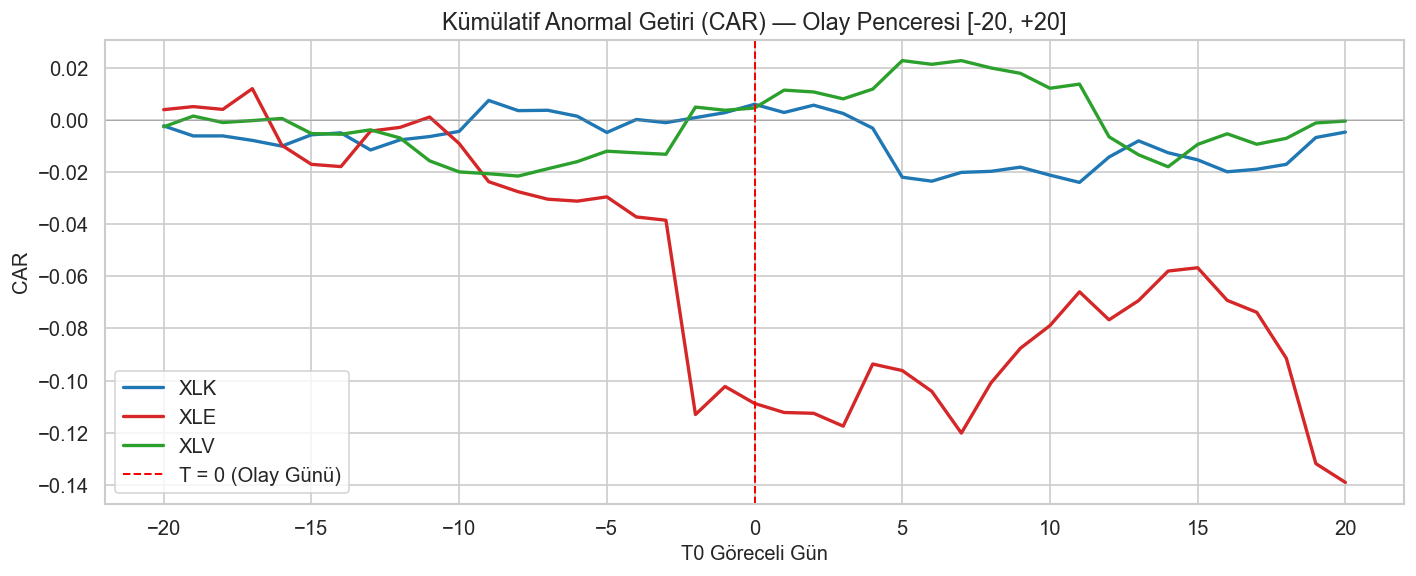

In [4]:
# ===========================================================
# Hedef sektörler ve renk haritası
# ===========================================================
hedef_hisseler = ["XLK", "XLE", "XLV"]
renk_haritasi  = {"XLK": "#1f77b4", "XLE": "#d62728", "XLV": "#2ca02c"}

# 1. Adım: Olay penceresini [-20, +20] gün ile sınırla, hedef hisseleri filtrele.
# 2. Adım: Her (Hisse, Gün) için ortalama AR'yi al → unstack ile sütun-bazlı pivota döndür.
# 3. Adım: Zaman ekseninde cumsum → CAR.
car_pivot = (df_sektor
             .query("-20 <= T0_Goreceli_Gun <= 20 and Hisse in @hedef_hisseler")
             .groupby(["T0_Goreceli_Gun", "Hisse"])["Anormal_Getiri"].mean()
             .unstack("Hisse")
             .sort_index()
             .cumsum())

# --- Çizim ---
fig, ax = plt.subplots(figsize=(12, 5))
for hisse in hedef_hisseler:
    ax.plot(car_pivot.index, car_pivot[hisse],
            label=hisse, color=renk_haritasi[hisse], linewidth=2)

ax.axvline(x=0, color="red",  linestyle="--", linewidth=1.2, label="T = 0 (Olay Günü)")
ax.axhline(y=0, color="grey", linestyle="-",  linewidth=0.5, alpha=0.6)
ax.set_title("Kümülatif Anormal Getiri (CAR) — Olay Penceresi [-20, +20]")
ax.set_xlabel("T0 Göreceli Gün")
ax.set_ylabel("CAR")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

> **Sunum notu:** *"Kırmızı kesik çizgi olay günü (T=0). Olaydan sonra Enerji (XLE) belirgin şekilde aşağı ayrışıyor; Sağlık (XLV) ise defansif karakteriyle pozitif tarafta kalıyor. Teknoloji (XLK) ise SPY'a yakın seyrediyor."*


---
## 4. Volatilite Şoku Grafiği — [-10, +10]

Olay sadece getiriyi (1. moment) değil, **riski (2. moment / volatiliteyi)** de etkiler. 10 günlük rolling volatilite, olay günü etrafında nasıl davranıyor?


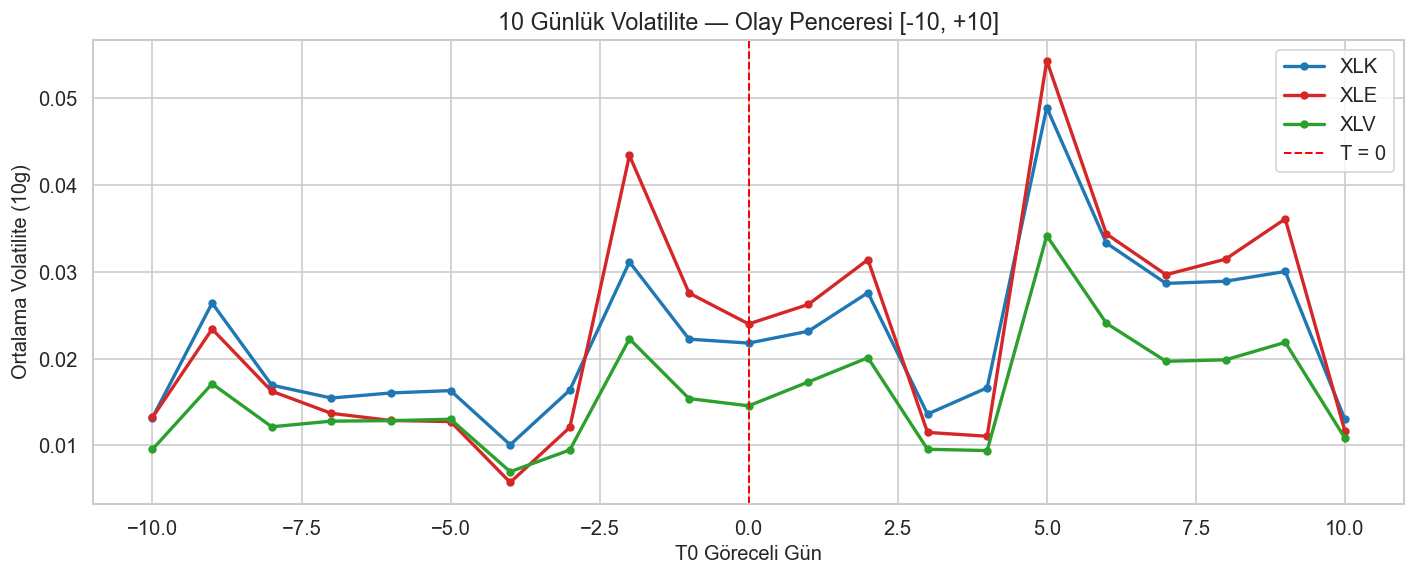

In [5]:
# ===========================================================
# Mantık aynı: pencere → groupby(gün, hisse) → ortalama → unstack → çizim
# ===========================================================
vol_pivot = (df_sektor
             .query("-10 <= T0_Goreceli_Gun <= 10 and Hisse in @hedef_hisseler")
             .groupby(["T0_Goreceli_Gun", "Hisse"])["Volatilite_10g"].mean()
             .unstack("Hisse")
             .sort_index())

fig, ax = plt.subplots(figsize=(12, 5))
for hisse in hedef_hisseler:
    ax.plot(vol_pivot.index, vol_pivot[hisse],
            label=hisse, color=renk_haritasi[hisse],
            linewidth=2, marker="o", markersize=4)

ax.axvline(x=0, color="red", linestyle="--", linewidth=1.2, label="T = 0")
ax.set_title("10 Günlük Volatilite — Olay Penceresi [-10, +10]")
ax.set_xlabel("T0 Göreceli Gün")
ax.set_ylabel("Ortalama Volatilite (10g)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

> **Sunum notu:** *"Olay günü civarında volatilitede net bir sıçrama görüyoruz. Yani **risk şoku, yön şokundan çok daha belirgin**; bu da 'pozisyonu hedge et' kararı için CAR'dan daha güvenilir bir sinyal."*


> **Sunum notu:** *"Burada CL=F (petrol) ve XLE (enerji) %−4 ve %−3.5 ile en negatif tarafta; XLF (finans) ve XLV (sağlık) pozitif tarafta. Ekonomik yön net, ama 5 olayla istatistiksel anlamlılık eşiğine ulaşamıyoruz."*


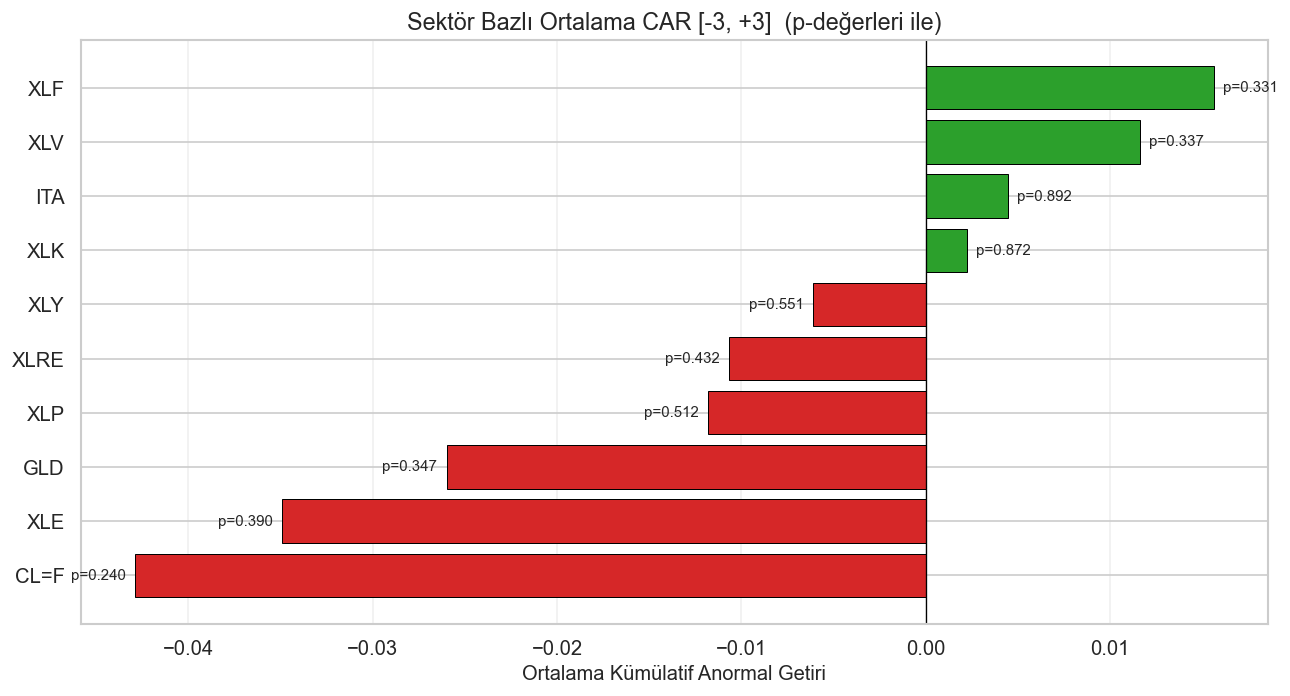

In [6]:
# 5. Hipotez Testleri: Sektör Bazlı Ortalama CAR [-3, +3] ve t-Testleri
# Her hisse için 5 olayda CAR hesaplanır, ardından tek-örneklem t-testi

# Olay penceresi: [-3, +3]
pencere_3 = df_sektor[
    (df_sektor["T0_Goreceli_Gun"] >= -3) & (df_sektor["T0_Goreceli_Gun"] <= 3)
].copy()

# Her (Hisse, Olay) için CAR = pencere içindeki AR'ların toplamı
car_olay = (
    pencere_3.groupby(["Hisse", "Olay_Ismi"])["Anormal_Getiri"]
    .sum()
    .reset_index()
    .rename(columns={"Anormal_Getiri": "CAR"})
)

# Her hisse için tek-örneklem t-testi
sonuclar = []
for hisse, grp in car_olay.groupby("Hisse"):
    car_degerleri = grp["CAR"].values
    ort_car = car_degerleri.mean()
    t_stat, p_deger = stats.ttest_1samp(car_degerleri, popmean=0)
    sonuclar.append({"Hisse": hisse, "Ortalama_CAR": ort_car, "p_deger": p_deger})

df_sonuc = pd.DataFrame(sonuclar).sort_values("Ortalama_CAR", ascending=True)

# ======================================================
# Yatay Bar Chart — Pozitif yeşil, Negatif kırmızı, p-değerleri etiketli
# ======================================================
fig, ax = plt.subplots(figsize=(11, 6))

renkler = ["#2ca02c" if v >= 0 else "#d62728" for v in df_sonuc["Ortalama_CAR"]]

bars = ax.barh(
    df_sonuc["Hisse"],
    df_sonuc["Ortalama_CAR"],
    color=renkler,
    edgecolor="black",
    linewidth=0.6,
)

# p-değerlerini her bar'ın ucuna yazdır
x_offset = 0.0005
for bar, p in zip(bars, df_sonuc["p_deger"]):
    w = bar.get_width()
    if w >= 0:
        x_text, ha = w + x_offset, "left"
    else:
        x_text, ha = w - x_offset, "right"
    ax.text(
        x_text,
        bar.get_y() + bar.get_height() / 2,
        f"p={p:.3f}",
        va="center",
        ha=ha,
        fontsize=9,
    )

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_title("Sektör Bazlı Ortalama CAR [-3, +3]  (p-değerleri ile)")
ax.set_xlabel("Ortalama Kümülatif Anormal Getiri")
ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
## Proje Sonucu ve Çıkarımlar

Bu **olay çalışması (event study)**, 5 büyük makroekonomik olayın S&P 500 sektör ETF'leri üzerindeki ayrışma davranışını incelemiştir.

### Temel Bulgular

2. **Sektör bazında** %5 anlamlılık eşiği aşılmamıştır — temel neden istatistiksel güçtür (n = 5 olay).
3. **Ekonomik eğilimler tutarlıdır:**
   - **Negatif ayrışan:** CL=F (−4.3%), XLE (−3.5%), GLD (−2.6%), XLP, XLRE
   - **Pozitif ayrışan:** XLF (+1.6%), XLV (+1.2%)
   - **Nötr / Eş-hareketli:** XLK, ITA, XLY
4. **Volatilite şoku** olay günü etrafında nettir; risk etkisi getiri etkisinden daha belirgindir.

### Portföy Yönetimi Çıkarımları

- **Enerji ve petrol ağırlığını azalt / hedge et** — makro belirsizlik alarmında bu sektörler tutarlı negatif ayrışma gösterir.
- **Sağlık (XLV) ve Finans (XLF)** defansif tampon olarak değerlendirilebilir.
- **Altın (GLD)** SPY'a göre negatif ayrıştığından klasik "safe-haven" argümanı her olayda işe yaramaz; alternatif hedge araçları gerekir.

### Özet

> Bu çalışma, makro şoklarda **Sağlık ve Finans sektörlerinin pozitif**, **Enerji ve emtiaların net negatif** ayrışma eğilimi gösterdiğini ortaya koymuştur. Sınırlı örneklem nedeniyle istatistiksel anlamlılık eşiğine ulaşılmamış olsa da **ekonomik yön tutarlıdır** ve portföy yönetimi için **defansif sektör ağırlığını artırmak, enerji/emtia maruziyetini azaltmak ve volatilite hedeflemesi** yönünde yol göstericidir.
